In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns
import matplotlib.pyplot as plt

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Harsh Kaushik\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
df_DA_india=df[(df['job_title']=='Data Analyst') & (df['job_country']=='India')].copy()
df_DA_india['job_posted_month_no']=df_DA_india['job_posted_date'].dt.month
df_DA_india_explode=df_DA_india.explode('job_skills')

In [19]:
df_DA_india_pivot=df_DA_india_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_india_pivot.loc['Total']=df_DA_india_pivot.sum()
df_DA_india_pivot=df_DA_india_pivot[df_DA_india_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_india_pivot.drop('Total', inplace=True)

In [40]:
DA_totals=df_DA_india.groupby('job_posted_month_no').size()
df_DA_india_percent=df_DA_india_pivot.div(DA_totals/100,axis=0)

In [41]:
df_DA_india_percent = df_DA_india_percent.reset_index()

df_DA_india_percent['job_posted_month'] = df_DA_india_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_india_percent = df_DA_india_percent.set_index('job_posted_month')
df_DA_india_percent = df_DA_india_percent.drop(columns='job_posted_month_no')
df_DA_india_percent



job_skills,sql,python,excel,tableau,power bi,sas,r,aws,azure,javascript,...,react.js,sqlite,suse,swift,tidyr,unify,vb.net,watson,webex,wire
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,52.083333,38.194444,35.416667,28.472222,18.055556,25.000000,15.972222,4.166667,3.472222,7.638889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.694444,0.000000
Feb,54.237288,33.898305,38.983051,27.118644,20.338983,11.864407,19.491525,5.084746,5.932203,6.779661,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.847458,0.000000,0.000000
Mar,58.762887,25.773196,32.989691,30.927835,19.587629,10.309278,9.278351,7.216495,6.185567,3.092784,...,0.000000,0.000000,1.030928,1.030928,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Apr,56.565657,35.353535,35.353535,27.272727,23.232323,24.242424,16.161616,4.040404,8.080808,7.070707,...,1.010101,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
May,68.750000,39.062500,57.812500,37.500000,28.125000,15.625000,14.062500,6.250000,14.062500,4.687500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jun,53.763441,45.161290,36.559140,31.182796,24.731183,30.107527,24.731183,10.752688,9.677419,5.376344,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Jul,61.956522,40.217391,40.217391,41.304348,21.739130,21.739130,25.000000,5.434783,8.695652,5.434783,...,0.000000,0.000000,0.000000,0.000000,1.086957,0.00000,0.000000,0.000000,0.000000,0.000000
Aug,62.411348,41.134752,38.297872,33.333333,30.496454,17.021277,19.858156,14.184397,7.801418,4.964539,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Sep,57.831325,39.156627,35.542169,31.927711,25.903614,15.662651,16.265060,7.228916,3.012048,8.433735,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.60241,0.000000,0.000000,0.000000,0.000000


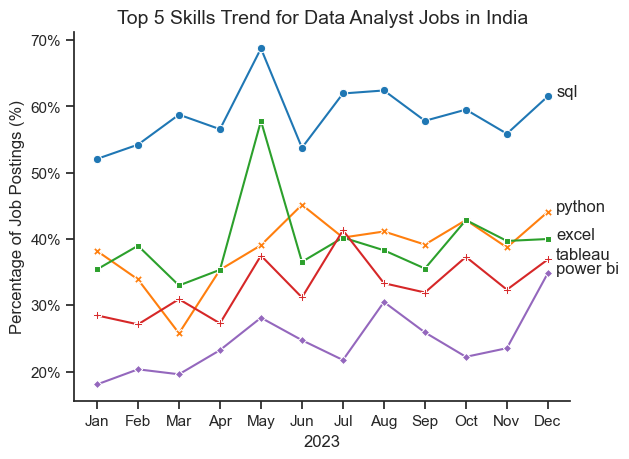

In [49]:
df_plot=df_DA_india_percent.iloc[:,:5]
sns.lineplot(data=df_plot, markers=True, dashes=False,palette='tab10')
sns.set_theme(style='ticks')

plt.title('Top 5 Skills Trend for Data Analyst Jobs in India', fontsize=14)
plt.xlabel('2023', fontsize=12)
plt.ylabel('Percentage of Job Postings (%)', fontsize=12)
plt.legend().remove()
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter())

for i in range(5):
    plt.text(11.2,df_plot.iloc[-1,i],df_plot.columns[i])

sns.despine()
